# **Forgery Detection**

In [4]:
!pip install kaggle --quiet

In [5]:
import json
import os
from google.colab import userdata
kaggle_dict={
    "username":userdata.get("KAGGLE_USERNAME"),
    "key":userdata.get('Key')
}

os.makedirs("/root/.kaggle",exist_ok=True)

with open("/root/.kaggle/kaggle.json","w") as f:
  json.dump(kaggle_dict,f)

! chmod 600 /root/.kaggle/kaggle.json

# from google.colab import files
# files.upload()

# import os
# os.makedirs("/roots/.kaggle",exist_ok=True)
# !mv kaggle.json /root/.kaggle/
# !chmod 600 /root/.kaggle/kaggle.json
# print("kaggle auth ready ")

In [6]:
# CASIA v2
!kaggle datasets download -d divg07/casia-20-image-tampering-detection-dataset \
    --unzip -p /content/casia

# CASIA ground truth
!git clone https://github.com/SunnyHaze/CASIA2.0-Corrected-Groundtruth \
    /content/casia/groundtruth


Dataset URL: https://www.kaggle.com/datasets/divg07/casia-20-image-tampering-detection-dataset
License(s): unknown
 97% 2.49G/2.56G [00:25<00:02, 32.9MB/s]
100% 2.56G/2.56G [00:25<00:00, 109MB/s] 
fatal: destination path '/content/casia/groundtruth' already exists and is not an empty directory.


In [7]:
from datasets import load_dataset
from huggingface_hub import login

login(token=userdata.get('HF_TOKEN'))

#loading the dataset and sacing on disk
dataset=load_dataset("dvgodoy/rvl_cdip_mini", split="train")
dataset.save_to_disk("/content/rvlcdip")
print(f"toatal images:{len(dataset)}")

Saving the dataset (0/1 shards):   0%|          | 0/3200 [00:00<?, ? examples/s]

toatal images:3200


In [8]:
import os
from datasets import load_from_disk

AUTH_DIR = "/content/casia/CASIA2/Au"
TAMP_DIR = "/content/casia/CASIA2/Tp"
MASK_DIR = "/content/casia/CASIA2/CASIA 2 Groundtruth"

print("CASIA authentic :", len(os.listdir(AUTH_DIR)))
print("CASIA tampered  :", len(os.listdir(TAMP_DIR)))
print("Ground truth    :", len(os.listdir(MASK_DIR)))

rvl = load_from_disk("/content/rvlcdip")
print("RVL-CDIP total  :", len(rvl))

CASIA authentic : 7492
CASIA tampered  : 5125
Ground truth    : 5123
RVL-CDIP total  : 3200


In [9]:
import os
import pandas as pd

AUTH_DIR = "/content/casia/CASIA2/Au"
TAMP_DIR = "/content/casia/CASIA2/Tp"
MASK_DIR = "/content/casia/CASIA2/CASIA 2 Groundtruth"

# Build mask lookup — strip _gt for matching
mask_lookup = {}
for f in os.listdir(MASK_DIR):
    base = f.replace("_gt.png", "")  # remove _gt suffix
    mask_lookup[base] = os.path.join(MASK_DIR, f)

records = []

# Authentic
for f in os.listdir(AUTH_DIR):
    if not f.lower().endswith((".jpg",".png",".tif",".bmp")):
        continue
    records.append({
        "file_id"        : f.rsplit(".",1)[0],
        "image_path"     : os.path.join(AUTH_DIR, f),
        "mask_path"      : None,
        "is_forged"      : 0,
        "forgery_type"   : "none",
        "source_dataset" : "CASIA_v2"
    })

# Tampered
for f in os.listdir(TAMP_DIR):
    if not f.lower().endswith((".jpg",".png",".tif",".bmp")):
        continue

    base         = f.rsplit(".",1)[0]
    mask_path    = mask_lookup.get(base, None)  # lookup using base name
    forgery_type = "copy_move" if "_CM_" in f or "CRN" in f \
                   else "splicing" if "_S_" in f \
                   else "unknown"

    records.append({
        "file_id"        : base,
        "image_path"     : os.path.join(TAMP_DIR, f),
        "mask_path"      : mask_path,
        "is_forged"      : 1,
        "forgery_type"   : forgery_type,
        "source_dataset" : "CASIA_v2"
    })

# RVL-CDIP
from datasets import load_from_disk
rvl = load_from_disk("/content/rvlcdip")

for i, sample in enumerate(rvl):
    records.append({
        "file_id"        : f"rvlcdip_{i:05d}",
        "image_path"     : f"rvlcdip_index_{i}",
        "mask_path"      : None,
        "is_forged"      : 0,
        "forgery_type"   : "none",
        "source_dataset" : "RVL_CDIP"
    })

# Build dataframe
df = pd.DataFrame(records)
df.to_csv("/content/master_labels.csv", index=False)

print(f"Total records : {len(df)}")
print(f"Authentic     : {len(df[df.is_forged==0])}")
print(f"Forged        : {len(df[df.is_forged==1])}")
print(f"With mask     : {df.mask_path.notna().sum()}")
print(f"\nForgery types:\n{df.forgery_type.value_counts()}")
print(f"\nSources:\n{df.source_dataset.value_counts()}")


Total records : 15814
Authentic     : 10691
Forged        : 5123
With mask     : 4981

Forgery types:
forgery_type
none         10691
splicing      3929
unknown        662
copy_move      532
Name: count, dtype: int64

Sources:
source_dataset
CASIA_v2    12614
RVL_CDIP     3200
Name: count, dtype: int64


In [10]:
df[7500:7550]

,file_id,image_path,mask_path,is_forged,forgery_type,source_dataset
7500,Tp_D_CRD_M_N_arc00037_ani00005_10142,/content/casia/CASIA2/Tp/Tp_D_CRD_M_N_arc00037...,/content/casia/CASIA2/CASIA 2 Groundtruth/Tp_D...,1,unknown,CASIA_v2
7501,Tp_S_NND_S_N_ind00100_ind00100_01379,/content/casia/CASIA2/Tp/Tp_S_NND_S_N_ind00100...,/content/casia/CASIA2/CASIA 2 Groundtruth/Tp_S...,1,splicing,CASIA_v2
7502,Tp_D_NRN_M_N_ani10144_nat10156_12472,/content/casia/CASIA2/Tp/Tp_D_NRN_M_N_ani10144...,/content/casia/CASIA2/CASIA 2 Groundtruth/Tp_D...,1,unknown,CASIA_v2
7503,Tp_S_NND_S_B_art00075_art00075_01245,/content/casia/CASIA2/Tp/Tp_S_NND_S_B_art00075...,/content/casia/CASIA2/CASIA 2 Groundtruth/Tp_S...,1,splicing,CASIA_v2
7504,Tp_D_NRN_M_N_nat00033_cha00070_11476,/content/casia/CASIA2/Tp/Tp_D_NRN_M_N_nat00033...,/content/casia/CASIA2/CASIA 2 Groundtruth/Tp_D...,1,unknown,CASIA_v2
7505,Tp_S_NRN_S_N_arc20070_arc20070_01710,/content/casia/CASIA2/Tp/Tp_S_NRN_S_N_arc20070...,/content/casia/CASIA2/CASIA 2 Groundtruth/Tp_S...,1,splicing,CASIA_v2
7506,Tp_D_NRN_S_N_cha00085_ind00098_10851,/content/casia/CASIA2/Tp/Tp_D_NRN_S_N_cha00085...,/content/casia/CASIA2/CASIA 2 Groundtruth/Tp_D...,1,splicing,CASIA_v2
7507,Tp_S_NRN_S_N_arc00081_arc00081_00301,/content/casia/CASIA2/Tp/Tp_S_NRN_S_N_arc00081...,/content/casia/CASIA2/CASIA 2 Groundtruth/Tp_S...,1,splicing,CASIA_v2
7508,Tp_D_NNN_S_B_arc20098_arc20030_02198,/content/casia/CASIA2/Tp/Tp_D_NNN_S_B_arc20098...,/content/casia/CASIA2/CASIA 2 Groundtruth/Tp_D...,1,splicing,CASIA_v2
7509,Tp_S_CRN_S_B_cha00021_cha00021_20025,/content/casia/CASIA2/Tp/Tp_S_CRN_S_B_cha00021...,/content/casia/CASIA2/CASIA 2 Groundtruth/Tp_S...,1,copy_move,CASIA_v2


Current dataset:

CASIA    → forged general images (nature, animals, objects)

RVL-CDIP → real documents only, NO forgeries

Problem:

Model has never seen a FORGED DOCUMENT

It only knows:
→ what forged general images look like

→ what real documents look like

→ never seen forged prescription/document

Solution:
Take RVL-CDIP real documents

Artificially forge them

So model learns document-specific forgery patterns


Real Document (RVL-CDIP)

        ↓
3 types of forgeries:


Type 1: Copy-Move

→ Copy a number/text region from same document

→ Paste it elsewhere in same document

→ e.g. copy "100" paste over "900"


Type 2: Splicing  

→ Take a region from another document

→ Paste into current document

→ e.g. paste different doctor stamp

Type 3: Text Region Tampering

→ Brighten/darken specific text area

→ Simulates erasing and rewriting

In [11]:
import torch
print(torch.cuda.is_available())

True


In [12]:
import cv2
import numpy as np
import pandas as pd
from datasets import load_from_disk
from PIL import Image
from tqdm import tqdm

#load the RVL-CDIP dataset from disk
rvl=load_from_disk("/content/rvlcdip")

# output directpries
os.makedirs("/content/synthetic/forged",exist_ok=True)
os.makedirs("/content/synthetic/masks",exist_ok=True)

rvl = load_from_disk("/content/rvlcdip")
print(f"generating forgery images for {len(rvl)} documents...")

generating forgery images for 3200 documents...


In [13]:
def generate_copy_move(image):
    """
    Copy a region from document and paste elsewhere
    Simulates: copying a number and pasting over another
    """
    img    = np.array(image.convert("RGB"))
    h, w   = img.shape[:2]
    mask   = np.zeros((h, w), dtype=np.uint8)

    # Random source region (copy from here)
    src_x  = np.random.randint(0, w // 2)
    src_y  = np.random.randint(0, h // 2)
    rw     = np.random.randint(30, w // 4)
    rh     = np.random.randint(10, h // 4)

    # Make sure region fits
    rw     = min(rw, w - src_x)
    rh     = min(rh, h - src_y)

    # Copy region
    region = img[src_y:src_y+rh, src_x:src_x+rw].copy()

    # Random destination (paste here)
    dst_x  = np.random.randint(0, w - rw)
    dst_y  = np.random.randint(0, h - rh)

    # Paste with slight blur to blend
    blurred = cv2.GaussianBlur(region, (3, 3), 0)
    img[dst_y:dst_y+rh, dst_x:dst_x+rw] = blurred

    # Mark tampered region in mask
    mask[dst_y:dst_y+rh, dst_x:dst_x+rw] = 255

    return img, mask

In [14]:
def generate_splicing(image1, image2):
    """
    Take region from doc1, paste into doc2
    Simulates: pasting different stamp/signature
    """
    img1   = np.array(image1.convert("RGB"))
    img2   = np.array(image2.convert("RGB"))
    h, w   = img1.shape[:2]
    mask   = np.zeros((h, w), dtype=np.uint8)

    # Resize img2 to match img1 if needed
    img2   = cv2.resize(img2, (w, h))

    # Random region from img2
    src_x  = np.random.randint(0, w // 2)
    src_y  = np.random.randint(0, h // 2)
    rw     = np.random.randint(30, w // 3)
    rh     = np.random.randint(10, h // 3)

    rw     = min(rw, w - src_x)
    rh     = min(rh, h - src_y)

    region = img2[src_y:src_y+rh, src_x:src_x+rw].copy()

    # Paste into img1 at random location
    dst_x  = np.random.randint(0, w - rw)
    dst_y  = np.random.randint(0, h - rh)

    img1[dst_y:dst_y+rh, dst_x:dst_x+rw] = region

    # Mark tampered region
    mask[dst_y:dst_y+rh, dst_x:dst_x+rw] = 255

    return img1, mask

In [15]:
def generate_text_tampering(image):
    """
    Brighten a text region — simulates erasing and rewriting
    """
    img    = np.array(image.convert("RGB"))
    h, w   = img.shape[:2]
    mask   = np.zeros((h, w), dtype=np.uint8)

    # Random narrow horizontal region (simulates a text line)
    x      = np.random.randint(0, w // 2)
    y      = np.random.randint(0, h - 20)
    rw     = np.random.randint(50, w // 2)
    rh     = np.random.randint(10, 30)   # narrow = one text line

    rw     = min(rw, w - x)
    rh     = min(rh, h - y)

    # Brighten that region (simulates whitening out text)
    region = img[y:y+rh, x:x+rw].astype(np.float32)
    region = np.clip(region * 1.8, 0, 255).astype(np.uint8)
    img[y:y+rh, x:x+rw] = region

    mask[y:y+rh, x:x+rw] = 255

    return img, mask

In [16]:
# Generate forgeries for all RVL-CDIP documents
synthetic_records = []
forgery_types     = ["copy_move", "splicing", "text_tamper"]

for i, sample in enumerate(tqdm(rvl, desc="Generating forgeries")):
    image        = sample["image"]
    forgery_type = forgery_types[i % 3]  # rotate between 3 types

    try:
        if forgery_type == "copy_move":
            forged_img, mask = generate_copy_move(image)

        elif forgery_type == "splicing":
            # Pick random different document for splicing
            j            = (i + np.random.randint(1, 100)) % len(rvl)
            image2       = rvl[j]["image"]
            forged_img, mask = generate_splicing(image, image2)

        else:
            forged_img, mask = generate_text_tampering(image)

        # Save forged image
        img_path  = f"/content/synthetic/forged/syn_{i:05d}.png"
        mask_path = f"/content/synthetic/masks/syn_{i:05d}_mask.png"

        cv2.imwrite(img_path,  cv2.cvtColor(forged_img, cv2.COLOR_RGB2BGR))
        cv2.imwrite(mask_path, mask)

        synthetic_records.append({
            "file_id"        : f"syn_{i:05d}",
            "image_path"     : img_path,
            "mask_path"      : mask_path,
            "is_forged"      : 1,
            "forgery_type"   : forgery_type,
            "source_dataset" : "SYNTHETIC"
        })

    except Exception as e:
        print(f"Failed {i}: {e}")
        continue

print(f"Generated {len(synthetic_records)} synthetic forgeries ✓")

Generating forgeries: 100%|██████████| 3200/3200 [01:48<00:00, 29.57it/s]

Generated 3200 synthetic forgeries ✓


In [17]:
# Merge synthetic records into master CSV
master_df    = pd.read_csv("/content/master_labels.csv")
synthetic_df = pd.DataFrame(synthetic_records)
final_df     = pd.concat([master_df, synthetic_df], ignore_index=True)
final_df.to_csv("/content/master_labels.csv", index=False)

print(f"Updated master CSV:")
print(f"Total          : {len(final_df)}")
print(f"Authentic      : {len(final_df[final_df.is_forged==0])}")
print(f"Forged         : {len(final_df[final_df.is_forged==1])}")
print(f"Sources        :\n{final_df.source_dataset.value_counts()}")
print(f"Forgery types  :\n{final_df.forgery_type.value_counts()}")


Updated master CSV:
Total          : 19014
Authentic      : 10691
Forged         : 8323
Sources        :
source_dataset
CASIA_v2     12614
RVL_CDIP      3200
SYNTHETIC     3200
Name: count, dtype: int64
Forgery types  :
forgery_type
none           10691
splicing        4996
copy_move       1599
text_tamper     1066
unknown          662
Name: count, dtype: int64


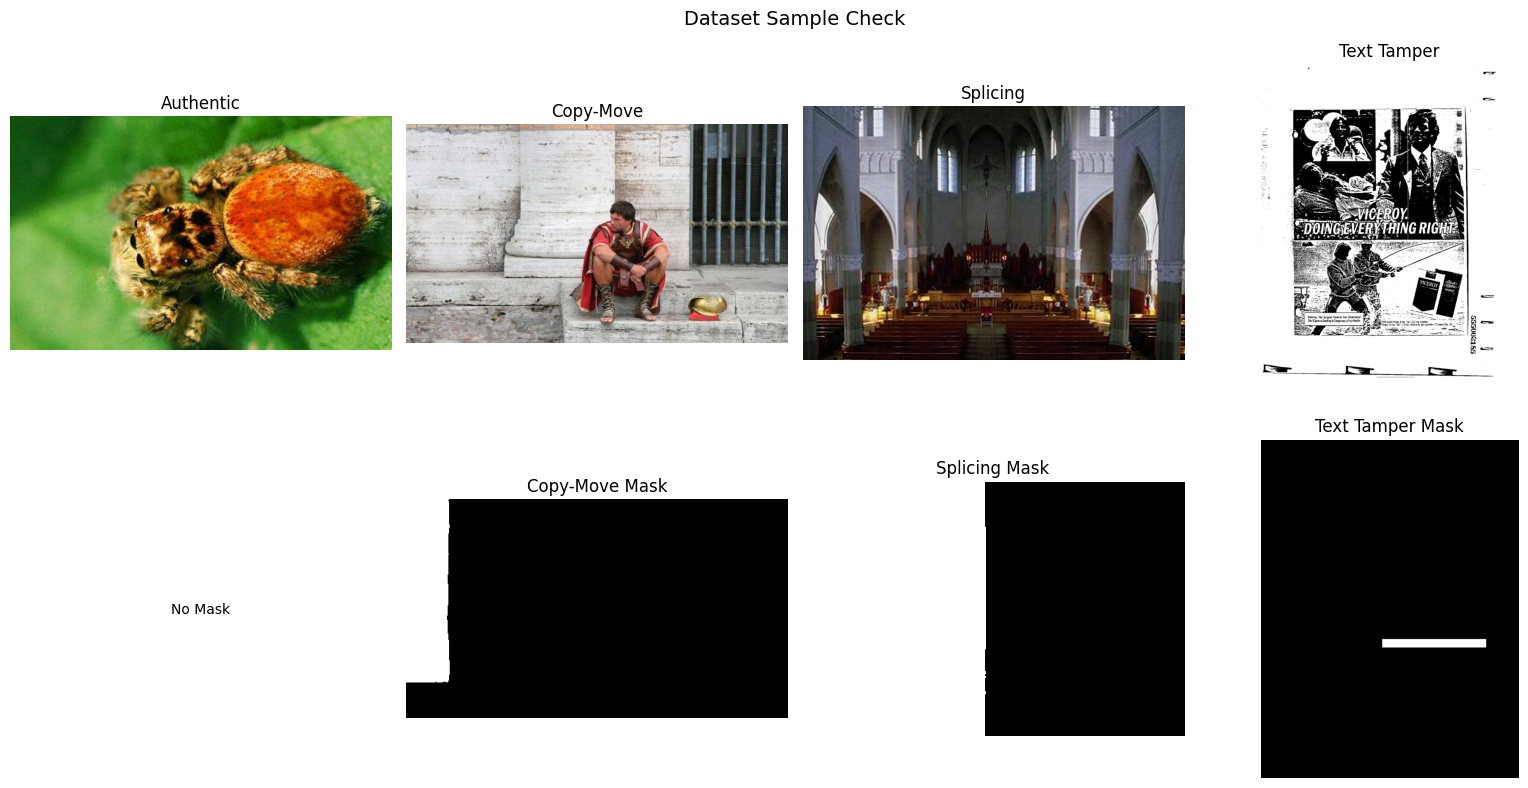

Sanity check complete ✓


In [18]:
import matplotlib.pyplot as plt
import cv2
import numpy as np
import pandas as pd

df = pd.read_csv("/content/master_labels.csv")

# Pick one sample from each type
authentic  = df[df.forgery_type == "none"].iloc[0]
copy_move  = df[df.forgery_type == "copy_move"].iloc[0]
splicing   = df[df.forgery_type == "splicing"].iloc[0]
text_tamp  = df[df.forgery_type == "text_tamper"].iloc[0]

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle("Dataset Sample Check", fontsize=14)

samples = [authentic, copy_move, splicing, text_tamp]
titles  = ["Authentic", "Copy-Move", "Splicing", "Text Tamper"]

for i, (sample, title) in enumerate(zip(samples, titles)):
    # Show image
    img = cv2.imread(sample["image_path"])
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    axes[0][i].imshow(img)
    axes[0][i].set_title(title)
    axes[0][i].axis("off")

    # Show mask if exists
    if pd.notna(sample["mask_path"]):
        mask = cv2.imread(sample["mask_path"], cv2.IMREAD_GRAYSCALE)
        axes[1][i].imshow(mask, cmap="gray")
        axes[1][i].set_title(f"{title} Mask")
    else:
        axes[1][i].text(0.5, 0.5, "No Mask",
                        ha="center", va="center")
    axes[1][i].axis("off")

plt.tight_layout()
plt.savefig("/content/dataset_check.png")
plt.show()
print("Sanity check complete ✓")

In [19]:
import torch
print("GPU       :", torch.cuda.get_device_name(0))
print("Memory    :", round(torch.cuda.get_device_properties(0).total_memory/1e9, 2), "GB")
print("PyTorch   :", torch.__version__)

GPU       : Tesla T4
Memory    : 15.64 GB
PyTorch   : 2.10.0+cu128


Practicing opencv

In [20]:
# from cv2.gapi import BGR2RGB
# import cv2
# from tqdm import tqdm
# import numpy as np
# import matplotlib.pyplot as plt
# from urllib.request import urlopen
# import requests
# from PIL import Image

# url='https://picsum.photos/seed/picsum/200/300'
# res=urlopen(url)
# image=np.array(bytearray(res.read()),dtype='uint8')
# image=cv2.imdecode(image,cv2.IMREAD_COLOR)
# # image=cv2.cvtColor(image,BGR2RGB)
# plt.imshow(image)
# plt.grid()
# plt.show()


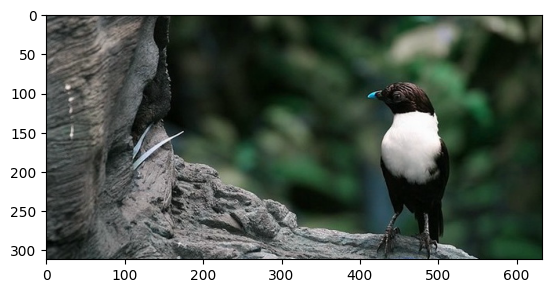

In [21]:
url='/content/casia/CASIA2/Au/Au_ani_10175.jpg'
image=cv2.imread(url)
plt.imshow(image)

In [22]:
print(image.shape)
print(image.dtype)
print(image.size)

(312, 633, 3)
uint8
592488


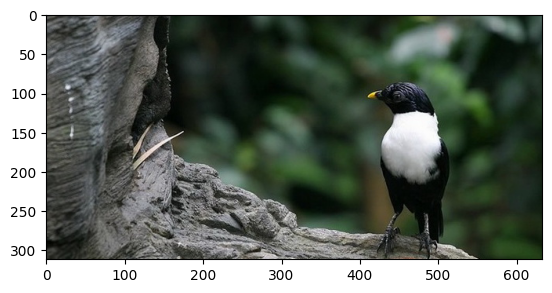

In [23]:
# print(image.shape)
# print(image.dtype)
# print(image.size)
image_url=cv2.cvtColor(image,cv2.COLOR_BGR2RGB)
plt.imshow(image_url)
plt.show()

(316, 550)


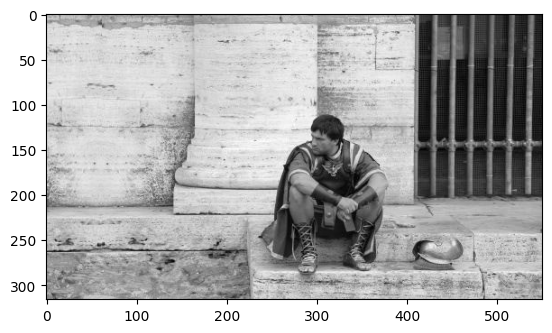

In [24]:
url = copy_move['image_path']
img=cv2.imread(url)
# plt.imshow(img)
image=cv2.cvtColor(img,cv2.COLOR_BGR2GRAY)
print(image.shape)
plt.imshow(image,cmap='gray')